In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches

In [ ]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.5       # 质量项
A = 1.0        # 费米速度项
B = 0.5        # 二阶动量项
Bz = 0.05  # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 10
xshumu = yshumu

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)


if m * B < 0:
    leiN = 1  # Topological
else:
    leiN = 0  # Trivial




Calculating Bands: 100%|██████████| 1001/1001 [00:00<00:00, 12947.42it/s]


1


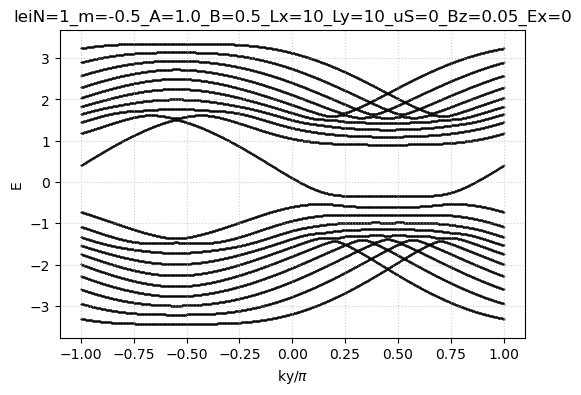

In [3]:
# 中间能带
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi,1001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.25,0.25)
#plt.xlim(-0.078,0.078)
#plt.ylim(-0.15,0.15)
#plt.xlim(-0.5,0.5)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
print(leiN)
plt.show()

In [7]:
# 两边纳米线 

def H_onsite_1(mx, mz, Bjiao, t):
    HX_block = -(mu - 2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz + mx*np.cos(Bjiao)*sx
    return HX_block

def H_hop_1(af, t):
    H_X_right_to_left_hop_block = -1 * (t*s0 + 1j*af*sz/(1*a))
    return H_X_right_to_left_hop_block

t = 2
tc=0.2*t
af = 50
mu = 0.5

hx = 0    # 0.5
hz = 0    # 0.95
saimanjiao = np.pi * 0

# 左边矩阵信息
H_L_onsite = H_onsite_1(hx, hz, saimanjiao, t)
H_L_right_to_left_hop = H_hop_1(0, t)

# 右边矩阵信息 
H_R_onsite = H_onsite_1(hx, hz, saimanjiao, t)
H_R_right_to_left_hop = H_hop_1(0, t)

# 输入矩阵
H_l = H_L_onsite
T_l = H_L_right_to_left_hop

H_r = H_R_onsite
T_r = H_R_right_to_left_hop.conj().T

Nd = 2

# 左电极耦合矩阵
T_LD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_LD[:, -Nd:] = H_hop_1(0, tc).conj().T
#T_LD[:, :Nd] = H_hop_1(0, t*0.7).conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_RD[:, -Nd:] = H_hop_1(0, tc)
#T_RD[:, 0:Nd] = H_hop_1(0, t*0.7).conj().T

In [3]:
#保存
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}"
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

save_dir = rf"D:\结果\2026.4.21下下"
os.makedirs(save_dir, exist_ok=True)

def save_fig_by_title_1(name):
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
    filename = os.path.join(save_dir, safe_name + ".png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

save = True 


def save_data_to_txt(x_data, y_data, filename, save_dir, header_text="X_Data\tY_Data"):
    """
    通用 txt 数据保存函数
    :param x_data: x 轴数据 (比如 Bz_values)
    :param y_data: y 轴数据 (比如 G_values)
    :param filename: 保存的文件名 (不需要加 .txt 后缀)
    :param save_dir: 保存的文件夹路径
    :param header_text: txt 文件第一行的表头说明
    """
    # 确保文件夹存在
    os.makedirs(save_dir, exist_ok=True)
    
    # 替换文件名中可能导致报错的非法字符
    safe_name = filename
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')
        
    # 拼接完整路径
    filepath = os.path.join(save_dir, safe_name + ".txt")
    
    # 将 x 和 y 拼成两列矩阵
    data_matrix = np.column_stack((x_data, y_data))
    
    # 写入 txt，使用科学计数法保留 8 位小数，以 tab 键分割
    np.savetxt(filepath, data_matrix, fmt='%.8e', delimiter='\t', header=header_text, comments='# ')
    print(f"✅ 数据已成功保存至: {filepath}")

In [5]:
#function
#T_l不可逆
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    # N 就是 yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 对于你来说，这里应该是 4 * xshumu
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r,Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

固定 Bz = 0.05, 开始使用 RGF 算法扫描能量 E 并计算电导...


Calculating Conductance vs Energy: 100%|██████████| 1001/1001 [00:08<00:00, 114.27it/s]


已保存图片: D:\结果\2026.4.21下下\G_leiN=1_m=-0.5_A=1.0_B=0.5_x=10_uS=0_Ex=0_Bz=0.05.png


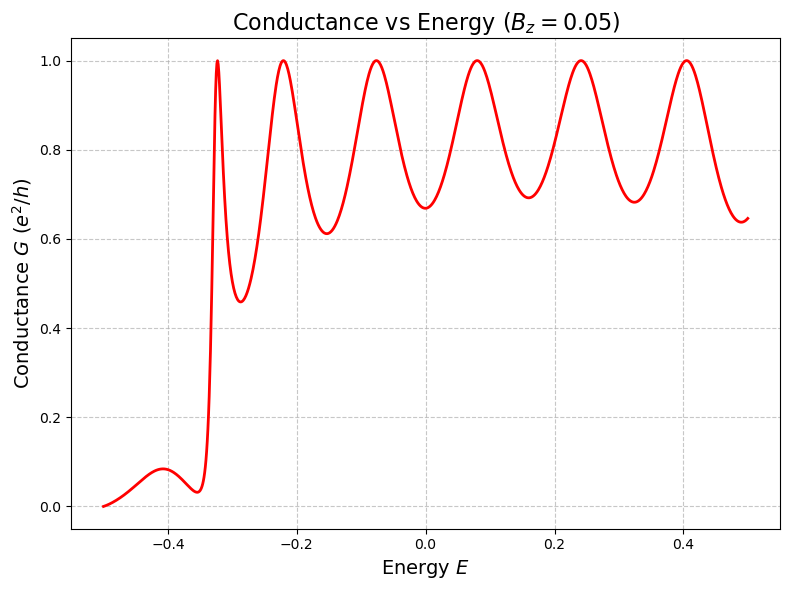

5.0


In [33]:
# 设定固定的 Bz 和要扫描的能量 E 范围
Bz = 0.05
E_values = np.linspace(-0.5, 0.5, 1001)  
G_values = []
eta = 1e-6

print(f"固定 Bz = {Bz}, 开始使用 RGF 算法扫描能量 E 并计算电导...")

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)
T_21 = H_hop(B, a, A, xshumu, Nd,Bz)
#H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz, yshumu) 

for E in tqdm(E_values, desc="Calculating Conductance vs Energy"):

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)


    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)


    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)

    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))  


plt.plot(E_values, G_values, linestyle='-', color='r', linewidth=2)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(rf'Conductance vs Energy ($B_z = {Bz}$)', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


params_str_1 = f"leiN={leiN}_m={m}_A={A}_B={B}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
save_fig_by_title_1('G_' + params_str_1)


plt.show()
print(Bz*yshumu*xshumu )

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导...


Scanning Bz: 100%|██████████| 1001/1001 [00:11<00:00, 84.20it/s]


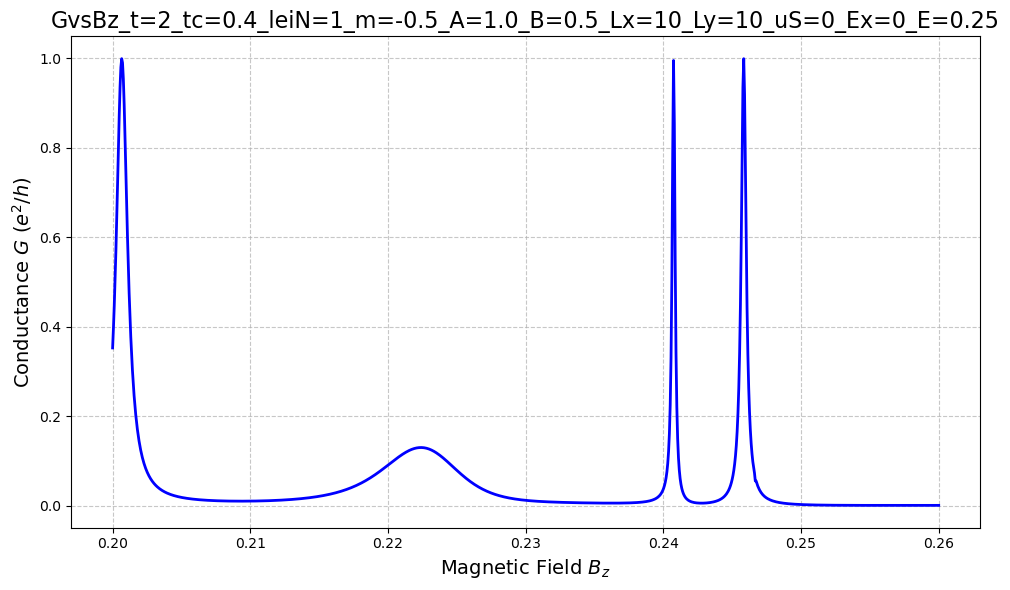

In [12]:
# 设定固定的 E 和要扫描的 Bz 范围
E = 0.25
Bz_values = np.linspace(0.2, 0.26, 1001)
G_values = []
eta = 1e-7
params_str_1 = f"t={t}_tc={tc}_leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}_E={E}"

print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导...")


for Bz_1 in tqdm(Bz_values, desc="Scanning Bz"):

    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd,Bz_1)

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)


    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    G_values.append(G_real)


plt.figure(figsize=(10, 6)) 

plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'GvsBz_{params_str_1}', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 更新保存命名（去掉超导参数 delta）
#save_fig_by_title_1('G_vs_Bz'+params_str_1)

# 显示图像
plt.show()

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...


Scanning Bz (Parallel): 100%|██████████| 1501/1501 [00:00<00:00, 2810.78it/s]


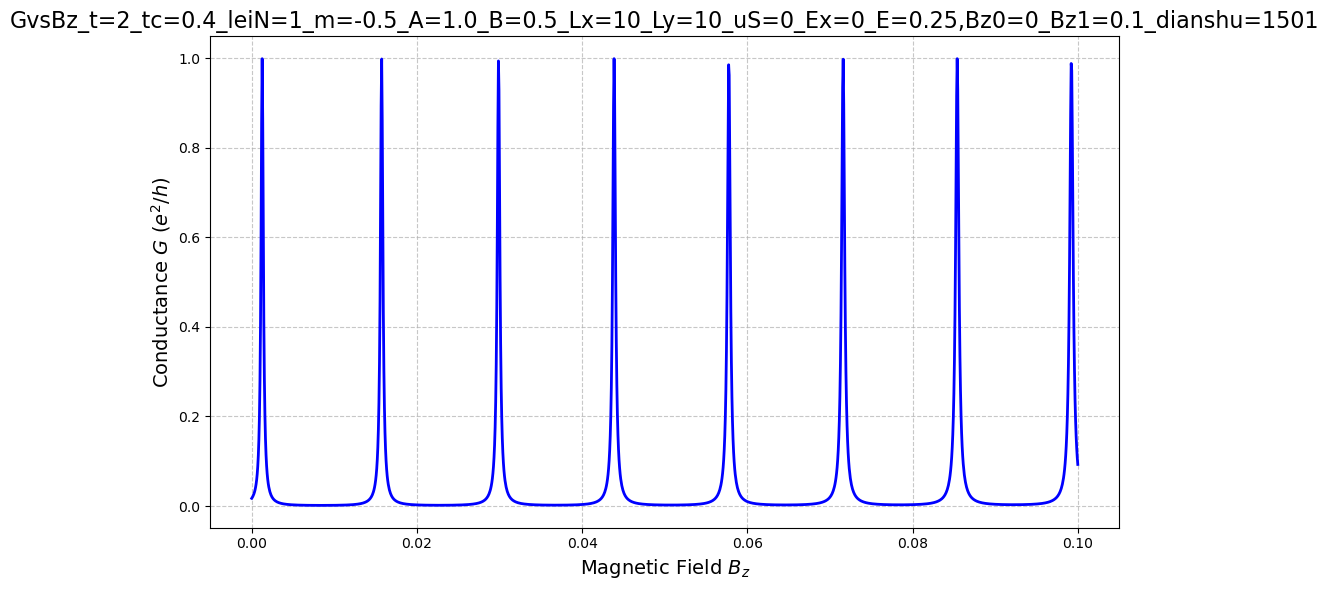

In [9]:
# 设定固定的 E 和要扫描的 Bz 范围 多核心计算
E = 0.25
Bz0 = 0
Bz1 = 0.1
dianshu = 1501
Bz_values = np.linspace(Bz0, Bz1, dianshu)
eta = 1e-6

# 定义保存路径
save_dir = rf"D:\结果\2026.4.21下下"
params_str_1 = f"t={t}_tc={tc}_leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}_E={E},Bz0={Bz0}_Bz1={Bz1}_dianshu={dianshu}"

print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...")

# ==========================================
# 核心修改：将循环内的计算逻辑打包成一个独立函数
# ==========================================
def calc_single_Bz(Bz_1):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    # ⚠️ 如果正式算磁场，记得这里要更新右电极！(遵照你的要求，这里保持注释状态不动)
    # H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu)

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

# ==========================================
# 使用 joblib 的 Parallel 开启 14 个 Worker 同时跑
# ==========================================
G_values = Parallel(n_jobs=14)(
    delayed(calc_single_Bz)(Bz_1) for Bz_1 in tqdm(Bz_values, desc="Scanning Bz (Parallel)")
)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(10, 6)) 
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'GvsBz_{params_str_1}', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

if 3==2:
    # 保存图片
    save_fig_by_title_1('G_vs_Bz_' + params_str_1)

    # ----------------- 保存数据部分 -----------------
    # 调用刚才写好的数据保存函数
    save_data_to_txt(
        x_data=Bz_values, 
        y_data=G_values, 
        filename='G_vs_Bz_shuju_' + params_str_1, 
        save_dir=save_dir,
        header_text="Bz\tConductance_G"
    )

# 显示图像
plt.show()

In [60]:
# 本征态
k_target = 0.078 * np.pi
# 计算 k 时的哈密顿量 (这里假设你的 Hk 函数已经定义好)
H_k0 = Hk(k_target, H_q, T_21)

# 注意：去掉了字符串里的 del={delta}，因为 2x2 系统不再有超导项
param_folder = f"leiN={leiN}_k={k_target:.4f}__m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
save_dir = rf"D:\结果\2026.4.21下下\{param_folder}"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 求解本征值和本征态
evals, evecs = np.linalg.eigh(H_k0)

Nd = 2  # 核心修改 1：现在每个格点只有 2 个自由度 (e↑, e↓)
print(f"\n开始计算 k={k_target} 的本征态波函数...")
print(f"共 {len(evals)} 个态，正在保存至 {save_dir} ...")

# sz 算符降维，只保留电子的极化权重
sz_local = np.array([1, -1])  # 对应 (e↑, e↓) 的自旋/轨道极化权重

# 扩展成整个波函数长度的极化权重向量 (长度为 Nd * xshumu)
Sz_weights = np.tile(sz_local, xshumu)

# 🌟 新增：构造位置 X 的权重向量。
# np.arange 生成 [0, 1, ..., xshumu-1]，np.repeat 让每个位置重复 Nd=2 次，变成 [0, 0, 1, 1, 2, 2, ...]
X_weights = np.repeat(np.arange(xshumu), Nd)

for i in tqdm(range(len(evals)), desc="Saving Wavefunctions"):
    E = evals[i]
    psi = evecs[:, i] 
    
    # ---------------- 计算期望值 ----------------
    prob = np.abs(psi)**2
    # 归一化波函数概率
    prob = prob / np.sum(prob) 
    
    # 计算极化期望值
    sz_exp = np.sum(prob * Sz_weights)
    
    # 🌟 新增：计算位置 X 的期望值 (即各位置概率加起来乘以对应的坐标位置)
    x_exp = np.sum(prob * X_weights)
    # --------------------------------------------------------
    
    # 画图：
    plt.figure(figsize=(10, 5))
    
    # 只需要 2 种颜色：红(e↑), 蓝(e↓)
    color_map = ['#d62728', '#1f77b4'] 
    
    # 循环生成 柱子的颜色
    colors = [color_map[j % Nd] for j in range(xshumu * Nd)]
    
    # 画柱状图，X轴从 0 到 Nd*xshumu - 1
    x_positions = np.arange(xshumu * Nd)
    plt.bar(x_positions, prob, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # 画垂直的灰色虚线，把第0个格点、第1个格点...隔开
    for j in range(xshumu + 1):
        plt.axvline(x=j * Nd - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 🌟 修改：设置图表标题，在最后面加上了 $\langle X \rangle$ 的值
    plt.title(fr"Detailed {xshumu*Nd}-Component Probability (k={k_target:.4f})\n$E = {E:.4f}$, $\langle S_z \rangle = {sz_exp:.2f}$, $\langle X \rangle = {x_exp:.4f}$", fontsize=16)
    
    plt.xlabel(fr"Component Index (0 to {Nd*xshumu-1})", fontsize=14)
    plt.ylabel(r"$|\psi|^2$", fontsize=14)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.xticks(x_positions, x_positions, fontsize=7)
    plt.xlim(-1, xshumu * Nd)
    # plt.ylim(0, 0.2) # 如果需要看清微小概率可以取消注释
    
    # 图例只保留电子项
    labels = [r'Electron $\uparrow$ (e_up)', r'Electron $\downarrow$ (e_dn)']
    patches = [mpatches.Patch(color=color_map[k], label=labels[k]) for k in range(Nd)]
    plt.legend(handles=patches, loc='upper right')
    
    # 文件命名依然加上 Sz 期望值
    filename = f"E_{E:.4f}_Sz_{sz_exp:.4f}_idx_{i}.png"
    filepath = os.path.join(save_dir, filename)
    
    # 保存并关闭画布
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()

print("全部波函数图片保存完毕！")


开始计算 k=0.24504422698000386 的本征态波函数...
共 100 个态，正在保存至 D:\结果\2026.4.21下下\leiN=1_k=0.2450__m=-0.5_A=1.0_B=0.5_Lx=50_Ly=50_uS=0_Bz=0.32_Ex=0 ...


Saving Wavefunctions: 100%|██████████| 100/100 [00:52<00:00,  1.92it/s]

全部波函数图片保存完毕！
